# Screening Status Classification — Logistic Regression vs. XGBoost
Predicts `screening_status` (Passed / Rejected) from applicant features in `result.csv`, compares Logistic Regression and XGBoost, and reports evaluation metrics plus feature importance.


## 1. Imports

In [1]:
# --- Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42


## 2. Load Data

In [2]:
# --- Load the dataset produced in the earlier screening step ---
CSV_PATH = "result.csv"  # update path if the file lives elsewhere


df = pd.read_csv(r"C:\Users\acer\Desktop\Project (2)\Result.csv")

print("Shape:", df.shape)
df.info()
df.head()


Shape: (1000, 15)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            1000 non-null   str    
 1   age                    1000 non-null   int64  
 2   gender                 1000 non-null   str    
 3   employment_status      1000 non-null   str    
 4   monthly_income         1000 non-null   float64
 5   loan_amount            1000 non-null   int64  
 6   emi                    1000 non-null   float64
 7   residual_income        1000 non-null   float64
 8   credit_score           1000 non-null   int64  
 9   dti                    1000 non-null   float64
 10  revolving_utilization  1000 non-null   float64
 11  credit_inquiries_12m   1000 non-null   int64  
 12  deterioration_pattern  1000 non-null   str    
 13  screening_status       1000 non-null   str    
 14  reject_reason          1000 non-null   str    
dty

,customer_id,age,gender,employment_status,monthly_income,loan_amount,emi,residual_income,credit_score,dti,revolving_utilization,credit_inquiries_12m,deterioration_pattern,screening_status,reject_reason
0,CUST150929,29,male,self-employed,5689.42,50000,1044.97,4644.45,732,0.34,0.41,3,stable,Rejected,"Low Residual Income (<8,000 THB)"
1,CUST166426,42,male,employed,9570.75,50000,791.57,8779.18,732,0.43,0.03,4,stable,Passed,Eligible
2,CUST167273,54,female,employed,6317.00,50000,1159.27,5157.73,619,0.39,0.35,5,stable,Rejected,"Low Residual Income (<8,000 THB)"
3,CUST219790,32,male,employed,6378.08,50000,1147.92,5230.16,742,0.16,0.40,2,sudden_shock,Rejected,"Low Residual Income (<8,000 THB)"
4,CUST143553,37,male,self-employed,18835.33,67683,1572.41,17262.92,639,0.37,0.04,3,stable,Passed,Eligible


## 3. Data Preprocessing
- Select the modeling features requested: `age`, `employment_status`, `monthly_income`, `emi`, `dti`, `revolving_utilization_origination`, `credit_inquiries_12m`, `residual_income`
- Encode `employment_status` (categorical text) with one-hot encoding
- Encode the target `screening_status` (Passed / Rejected) into 0 / 1
- Split into train / test sets (stratified, since classes are likely imbalanced)

In [4]:
# --- Select modeling features & target ---
FEATURE_COLS = [
    "age", "employment_status", "monthly_income", "emi", "dti",
    "revolving_utilization", "credit_inquiries_12m", "residual_income"
]
TARGET_COL = "screening_status"

model_df = df[FEATURE_COLS + [TARGET_COL]].copy()

# --- Encode target: Rejected = 1 (positive class of interest), Passed = 0 ---
target_encoder = LabelEncoder()
# Force a known order so "Rejected" always maps to 1, regardless of alphabetical default
model_df[TARGET_COL] = model_df[TARGET_COL].map({"Passed": 0, "Rejected": 1})

# --- One-hot encode the categorical feature ---
model_df = pd.get_dummies(model_df, columns=["employment_status"], drop_first=True)

X = model_df.drop(columns=[TARGET_COL])
y = model_df[TARGET_COL]

# --- Train-test split (stratified to preserve class balance) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True))

# --- Scaled versions (Logistic Regression benefits from scaling; XGBoost does not need it) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Train shape: (800, 9)  Test shape: (200, 9)
Train class balance:
 screening_status
1    0.54875
0    0.45125
Name: proportion, dtype: float64


## 4. Model 1 — Logistic Regression

In [5]:
# --- Train Logistic Regression on scaled features ---
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression — Classification Report")
print(classification_report(y_test, y_pred_lr, target_names=["Passed", "Rejected"]))


Logistic Regression — Classification Report
              precision    recall  f1-score   support

      Passed       0.95      0.88      0.91        90
    Rejected       0.91      0.96      0.93       110

    accuracy                           0.93       200
   macro avg       0.93      0.92      0.92       200
weighted avg       0.93      0.93      0.92       200



## 5. Model 2 — XGBoost

In [6]:
# --- Train XGBoost on raw (unscaled) features ---
xgb_clf = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=RANDOM_STATE
)
xgb_clf.fit(X_train, y_train)

y_pred_xgb = xgb_clf.predict(X_test)
y_proba_xgb = xgb_clf.predict_proba(X_test)[:, 1]

print("XGBoost — Classification Report")
print(classification_report(y_test, y_pred_xgb, target_names=["Passed", "Rejected"]))


XGBoost — Classification Report
              precision    recall  f1-score   support

      Passed       1.00      1.00      1.00        90
    Rejected       1.00      1.00      1.00       110

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



## 6. Evaluation Metrics Comparison

In [7]:
# --- Build a side-by-side metrics comparison table ---
def get_metrics(y_true, y_pred, model_name):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred)
    }

metrics_df = pd.DataFrame([
    get_metrics(y_test, y_pred_lr, "Logistic Regression"),
    get_metrics(y_test, y_pred_xgb, "XGBoost")
]).set_index("Model").round(4)

metrics_df


,Accuracy,Precision,Recall,F1-score
Model,,,,
Logistic Regression,0.925,0.906,0.9636,0.9339
XGBoost,1.000,1.000,1.0000,1.0000


## 7. Confusion Matrices

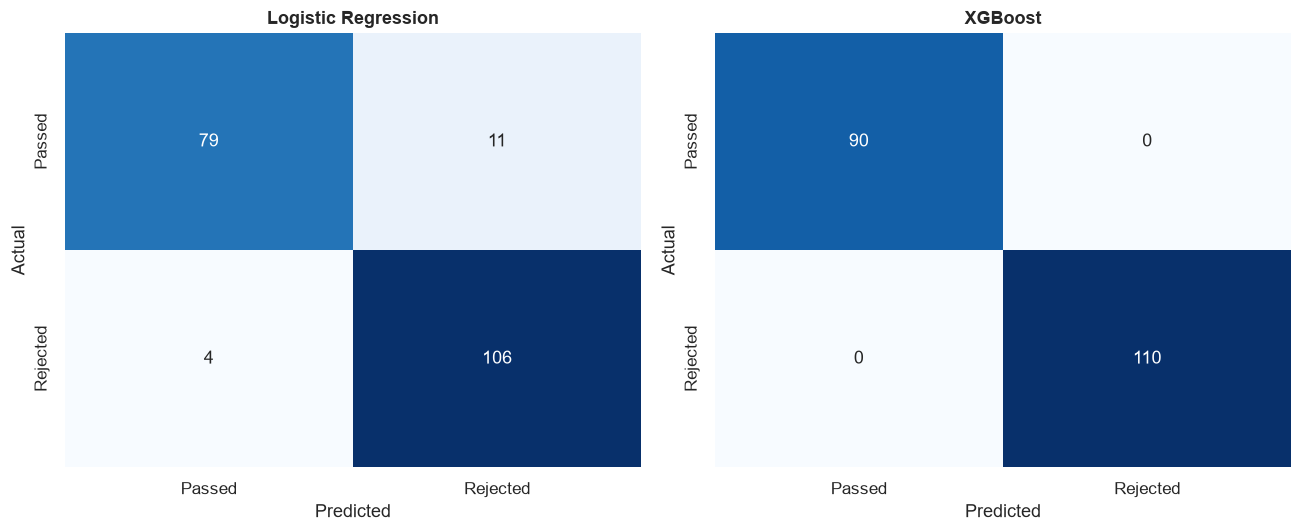

In [8]:
# --- Side-by-side confusion matrices ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_xgb],
    ["Logistic Regression", "XGBoost"]
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Passed", "Rejected"],
        yticklabels=["Passed", "Rejected"],
        ax=ax, cbar=False
    )
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


## 8. Feature Importance
XGBoost's built-in gain-based importance shows which features drive rejections most; Logistic Regression's coefficients (on standardized features) show direction and relative magnitude.

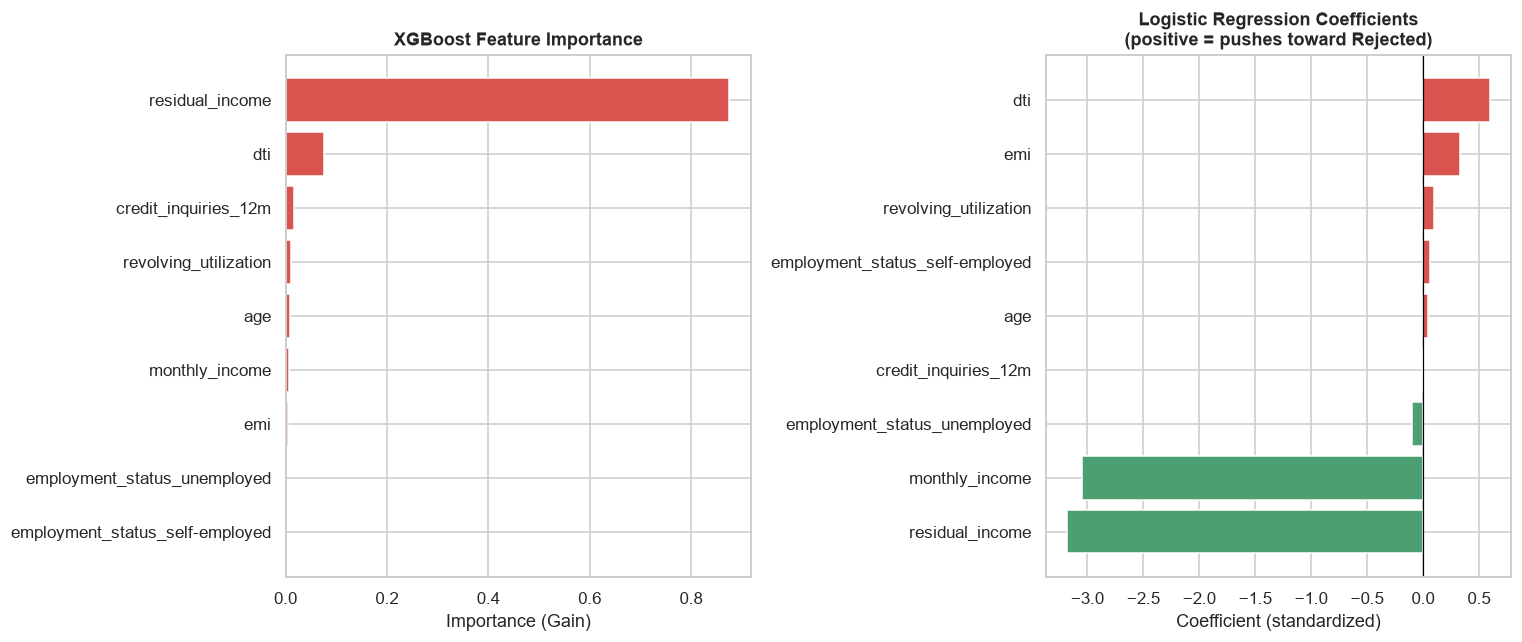

In [9]:
# --- XGBoost feature importance ---
xgb_importance = pd.Series(xgb_clf.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(xgb_importance.index, xgb_importance.values, color="#D9534F")
axes[0].set_title("XGBoost Feature Importance", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Importance (Gain)")

# --- Logistic Regression coefficients (standardized features -> comparable magnitudes) ---
lr_coefs = pd.Series(log_reg.coef_[0], index=X.columns).sort_values(ascending=True)
colors = ["#D9534F" if v > 0 else "#4C9F70" for v in lr_coefs.values]

axes[1].barh(lr_coefs.index, lr_coefs.values, color=colors)
axes[1].set_title("Logistic Regression Coefficients\n(positive = pushes toward Rejected)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Coefficient (standardized)")
axes[1].axvline(x=0, color="black", linewidth=0.8)

plt.tight_layout()
plt.show()
